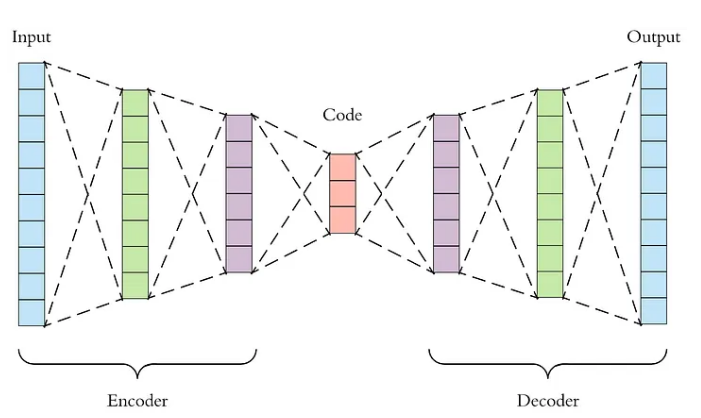

In [37]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [38]:
transform = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

In [39]:
train_data = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_data = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

In [40]:
batch_size = 64

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

In [41]:
print(len(train_data))
print(len(train_loader))
print(len(train_data) / batch_size)

60000
938
937.5


In [42]:
class AutoEncoder(nn.Module):

    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(), # 28 * 28 -> 784
            nn.Linear(in_features=28*28, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=64, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=28*28),
            nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1,28,28))
        )



    def forward(self, x):

        encoded = self.encoder(x)

        decoded = self.decoder(encoded)

        return decoded

In [43]:
class EarlyStopping:

    def __init__(self, patience = 5, min_delta = 0.001):
        
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, loss):
        
        if self.best_loss is None or loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
        else:
            self.counter +=1
        

        if self.counter >= self.patience:
            return True
        
        return False

In [44]:
epochs = 5
learning_rate = 0.001

In [45]:
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

In [46]:
def training(model, train_loader, optimizer, criterion, early_stopping, epochs):
    model.train()

    prev_loss = None

    for epoch in range(epochs):
        total_loss = 0
        for inputs, _ in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() # total los for 1 epoch



        avg_loss = total_loss/len(train_loader)

        if prev_loss is not None:
            loss_diff = prev_loss - avg_loss
            
            diff_text = f" | Difference Loss: {loss_diff:.6f}   min_delta: 0.001"
        else:
            diff_text = " | Difference Loss : ---" 

        print(f"Epoch: {epoch + 1} / {epochs},   Loss: {avg_loss:.6f}  min_delta: 0.001")
        print(f"{diff_text}")

        prev_loss = avg_loss

        if early_stopping(avg_loss):
            print(f"Early stopping at epoch {epoch + 1}")
            break

In [47]:
training(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, early_stopping=early_stopping, epochs=epochs)

Epoch: 1 / 5,   Loss: 0.032661  min_delta: 0.001
 | Difference Loss : ---


KeyboardInterrupt: 